# One-photon waveguide scattering without the RWA

Run from `codex/code/notebooks`. The dictionaries match `local_project`. The default calculation uses a total-photon cutoff and a right-moving incident photon. See `../documentation/main.pdf` for the full derivation.


In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from src.experiment import resource_estimation
from src.fidelities import fidelities_over_time
from experiments.scattering import run_scattering

pi = np.pi


## Waveguide initialization

In [78]:
param_photon = {'k_0': 1.0, 'sigma_k': 0.1, 'x_0': -5*pi, "right_moving_only": False}


param_atom = {'omega_0': 1.0, 
              'D': 1, 
              'x_tls': 0.0,
              'L': 20*pi, 
              'coupling': 'sqrt'}

param_time_evol = {'T': 10*pi, 'dt': 0.1}

cutoffs = {'ir_cutoff': 0, 'uv_cutoff': 2}
n_max = 3
truncation = 'full+totalcap'


estimate = resource_estimation(param_atom, param_time_evol, cutoffs, 
                               n_max=n_max, 
                               truncation=truncation)


Modes: 41; truncation: full+totalcap; ket dimension: 26,488
Output times: 315; ket/history: 0.124 GiB
Feasible: True (excludes Hamiltonian and Python objects)


In [79]:
experiment = run_scattering(param_photon, param_atom, param_time_evol, cutoffs, 
                            n_max=n_max, 
                            truncation=truncation,
                            RWA = False,
                            progress=True)

for name, values in experiment.observables.items():
    print(name, values[-1])


  0%|          | 0/314 [00:00<?, ?it/s]

time 31.400000000000002
norm 0.9999998650854326
p_excited 0.1143827265767259
p_transmitted 0.1151481573663163
p_reflected 0.5359998901348882
p_0_photon 0.00054466212397003
p_1_photon 0.6511480475012046
p_2_photon 0.11383806445275581
p_3_photon 0.2344690910075015


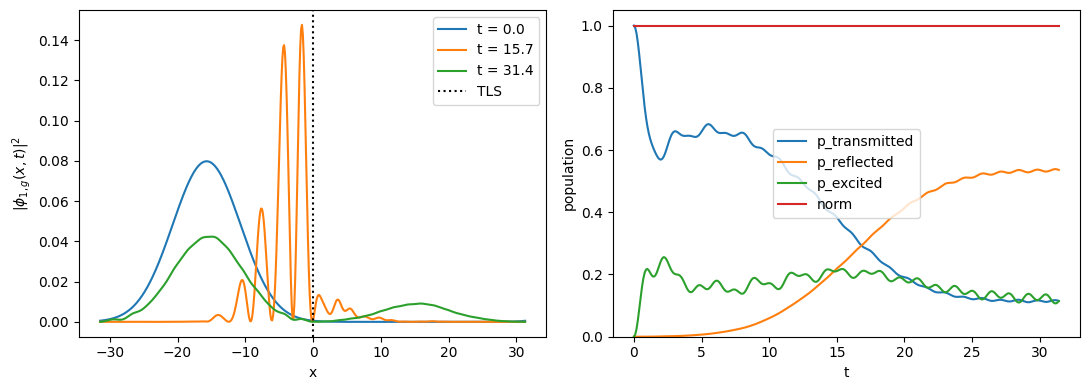

In [80]:
if experiment is not None:
    time = experiment.observables['time']
    x_tab = np.linspace(-param_atom['L']/2, param_atom['L']/2, 500, endpoint=False)
    t_hit = param_atom['x_tls'] - param_photon['x_0']
    snapshots = [0, np.argmin(np.abs(time - t_hit)), len(time)-1]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for j in snapshots:
        phi_x = experiment.one_photon_wavefunction(j, x_tab)
        axes[0].plot(x_tab, np.abs(phi_x)**2, label=f't = {time[j]:.1f}')
    axes[0].axvline(param_atom['x_tls'], color='black', ls=':', label='TLS')
    axes[0].set(xlabel='x', ylabel=r'$|\phi_{1,g}(x,t)|^2$')
    axes[0].legend()
    for name in ('p_transmitted', 'p_reflected', 'p_excited', 'norm'):
        axes[1].plot(time, experiment.observables[name], label=name)
    axes[1].set(xlabel='t', ylabel='population', ylim=(0, 1.05))
    axes[1].legend()
    fig.tight_layout()
    plt.show()


## Compare photon-space truncations

All calculations below use the same physical parameters and signed momentum grid. The photon fidelity is calculated exactly from a 2×2 overlap matrix.


In [ ]:
schemes = ('full+totalcap', 'truncated')
runs = {}
for scheme in schemes:
    estimate = resource_estimation(param_atom, param_time_evol, cutoffs, 
                                   n_max=n_max, 
                                   truncation=scheme)
    if estimate['feasible']:
        runs[scheme] = run_scattering(param_photon, param_atom, param_time_evol, cutoffs, 
                                      n_max=n_max, 
                                      truncation=scheme)

reference = runs.get('full+totalcap')
if reference is not None:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
    for scheme in ('truncated',):
        if scheme in runs:
            F = fidelities_over_time(runs[scheme], reference)
            for ax, name in zip(axes, ('state', 'atom', 'photon')):
                ax.plot(reference.times, F[name], label=scheme)
                ax.set(xlabel='t', ylabel=f'{name} fidelity', ylim=(0, 1.05))
                ax.set_title(name)
            print(scheme, 'initial:', F['state'][0],
                  'time mean:', {key: np.mean(value) for key, value in F.items()})
    axes[0].legend()
    fig.tight_layout()
    plt.show()


## Optional coupling sweep

Set `RUN_SWEEP=True` to obtain the time-mean fidelity versus the physical coupling parameter `D`. The default cell above uses one photon; for a coherent comparison, change `param_photon` before running.


In [ ]:
RUN_SWEEP = True
if RUN_SWEEP:
    D_values = np.geomspace(0.02, 0.45, 6)
    sweep = {scheme: [] for scheme in ('truncated',)}
    for D in D_values:
        atom_here = dict(param_atom, D=float(D))
        ref = run_scattering(param_photon, atom_here, param_time_evol, cutoffs,
                             n_max=n_max, truncation='full+totalcap')
        for scheme in sweep:
            candidate = run_scattering(param_photon, atom_here, param_time_evol,
                                       cutoffs, n_max=n_max, truncation=scheme)
            F = fidelities_over_time(candidate, ref)
            sweep[scheme].append(np.mean(F['state']))
    for scheme, values in sweep.items():
        plt.semilogx(D_values, values, 'o-', label=scheme)
    plt.xlabel('D')
    plt.ylabel('time-mean full-state fidelity')
    plt.legend()
    plt.show()
